In [11]:
from c3s_lib import *

import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle


In [12]:
# api key used for the DataClient
# replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

In [13]:
#2.1
# example of retrieving data for 15 days leading up to an event
eventDate = datetime(2020, 1, 1)        # event date
startDate = eventDate - timedelta(days=14)  # 15 days before the event date range is inclusive
bbox = (-5.0, -10.0, 15.0, 20.0)

# retrieve the data for the specified bounding box and date range
gdfs = DataClient(your_api_key).temperature_2m_mean(bbox, (startDate, eventDate))

2025-08-14 11:21:08,498 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-14 11:21:09,529 INFO Request ID is 862c4715-42b8-41c4-85d2-fbfcd242a5dd
2025-08-14 11:21:09,622 INFO status has been updated to accepted
2025-08-14 11:21:18,118 INFO status has been updated to running
2025-08-14 11:21:23,259 INFO status has been updated to successful


4c84bcc74f06ef7409c33773069e9a4b.nc:   0%|          | 0.00/303k [00:00<?, ?B/s]

2025-08-14 11:21:24,585 INFO Request ID is 4ee6967f-4c09-4be5-86e0-14f3b44b02e7
2025-08-14 11:21:24,655 INFO status has been updated to accepted
2025-08-14 11:21:38,293 INFO status has been updated to successful


8c7783fe14740279ff110147ba00dee.nc:   0%|          | 0.00/42.8k [00:00<?, ?B/s]

In [6]:
#2.1
# split dataframe into daily GeoDataFrames
daily_gdfs = {}
for date, gdf in gdfs.groupby(gdfs['valid_time'].dt.date):
    daily_gdfs[date] = gdf

# or make a selection of the data for a specific date range
gdf_selection = gdfs[(gdfs['valid_time'] >= eventDate) & (gdfs['valid_time'] <= eventDate)]

gdf_selection

,valid_time,latitude,longitude,t2m,number,geometry
137214,2020-01-01,20.0,-5.00,12.248108,0,POINT (-5 20)
137215,2020-01-01,20.0,-4.75,12.326660,0,POINT (-4.75 20)
137216,2020-01-01,20.0,-4.50,12.396973,0,POINT (-4.5 20)
137217,2020-01-01,20.0,-4.25,12.505188,0,POINT (-4.25 20)
137218,2020-01-01,20.0,-4.00,12.623047,0,POINT (-4 20)
...,...,...,...,...,...,...
147010,2020-01-01,-10.0,14.00,28.377686,0,POINT (14 -10)
147011,2020-01-01,-10.0,14.25,28.002930,0,POINT (14.25 -10)
147012,2020-01-01,-10.0,14.50,26.457520,0,POINT (14.5 -10)
147013,2020-01-01,-10.0,14.75,24.258453,0,POINT (14.75 -10)


In [6]:
def ddplot_gdf(gdf, borders=True, coastlines=True, gridlines=True, title=None, legend=True, legend_title=None, cmap='coolwarm', fig_size = (7,5), polygons:Polygon = None):
    
    fig, ax = plt.subplots(
        ncols = 1, nrows = 1, figsize = fig_size, dpi = 100, 
        subplot_kw = {"projection" : cartopy.crs.PlateCarree()}
        )   

    temp_kwargs = {"cmap" : cmap}

    legend_title = legend_title if legend_title else "legend"

    gdf.plot(ax = ax, **temp_kwargs,
        legend=legend, legend_kwds={'label': legend_title},
        column = 't2m',
        )

    if gridlines:
        ax.gridlines(
            crs=cartopy.crs.PlateCarree(), 
            linewidth=0.5, color='black', 
            draw_labels=["bottom", "left"], alpha=0.2
        )

    if coastlines:
        ax.coastlines()

    if borders:
        ax.add_feature(
            cartopy.feature.BORDERS, 
            lw = 1, alpha = 0.7, ls = "--", zorder = 99
        )

    if polygons != None:
        for poly in polygons:
            x, y = poly.exterior.xy
            ax.plot(x, y, color='red', linewidth=2, transform=ccrs.PlateCarree())

    # add box around area of interest
    if title != None:
        ax.set_title(title)

    return fig, ax


In [47]:
def ddsubplot_gdf(
    gdfs, datetime_col='valid_time', column='t2m', polygons=None,
    ncols=5, figsize=(20, 12), cmap='coolwarm', legend_title='Temperature (°C)',
    borders=True, coastlines=True, gridlines=True, suptitle=None
):
    # Ensure datetime column is datetime type
    gdfs[datetime_col] = pd.to_datetime(gdfs[datetime_col])

    # Unique days sorted
    unique_days = sorted(gdfs[datetime_col].dt.date.unique())
    n_plots = len(unique_days)
    nrows = math.ceil(n_plots / ncols)

    # Create subplots with Cartopy projection
    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize,
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    axes = axes.flatten()

    # Normalize color scale across all data
    vmin = gdfs[column].min()
    vmax = gdfs[column].max()

    for i, day in enumerate(unique_days):
        ax = axes[i]

        # Filter GeoDataFrame for this day
        day_gdf = gdfs[gdfs[datetime_col].dt.date == day]

        # Plot data on this subplot
        day_gdf.plot(
            ax=ax,
            column=column,
            cmap=cmap,
            legend=False,  # legend handled once globally
            vmin=vmin,
            vmax=vmax,
        )

        if gridlines:
            ax.gridlines(
                crs=ccrs.PlateCarree(),
                linewidth=0.5,
                color='black',
                draw_labels=["bottom", "left"],
                alpha=0.2
            )

        if coastlines:
            ax.coastlines()

        if borders:
            ax.add_feature(cartopy.feature.BORDERS, lw=1, alpha=0.7, ls="--")

        # Draw polygons if provided
        if polygons is not None:
            for poly in polygons:
                x, y = poly.exterior.xy
                ax.plot(x, y, color='red', linewidth=2, transform=ccrs.PlateCarree())

        ax.set_title(f"{day}", fontsize=10)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Add shared colorbar to the right
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    #cbar_ax = fig.add_axes([.2, .95, .6, .02])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation='horizontal', location="top", fraction=0.01, pad=.07, aspect=40)
    cbar.set_label(legend_title, labelpad=10, fontsize=12)

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)

    #plt.tight_layout(rect=[0, 0, 0.95, 0.95])  # leave room for suptitle and colorbar
    return fig, axes

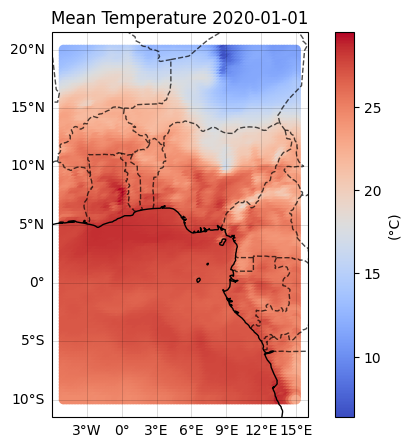

In [7]:
#2.1/2.2
fig, ax = plot_gdf(gdf_selection, title=f"Mean Temperature {eventDate.strftime('%Y-%m-%d')}", legend_title="(°C)", cmap='coolwarm')


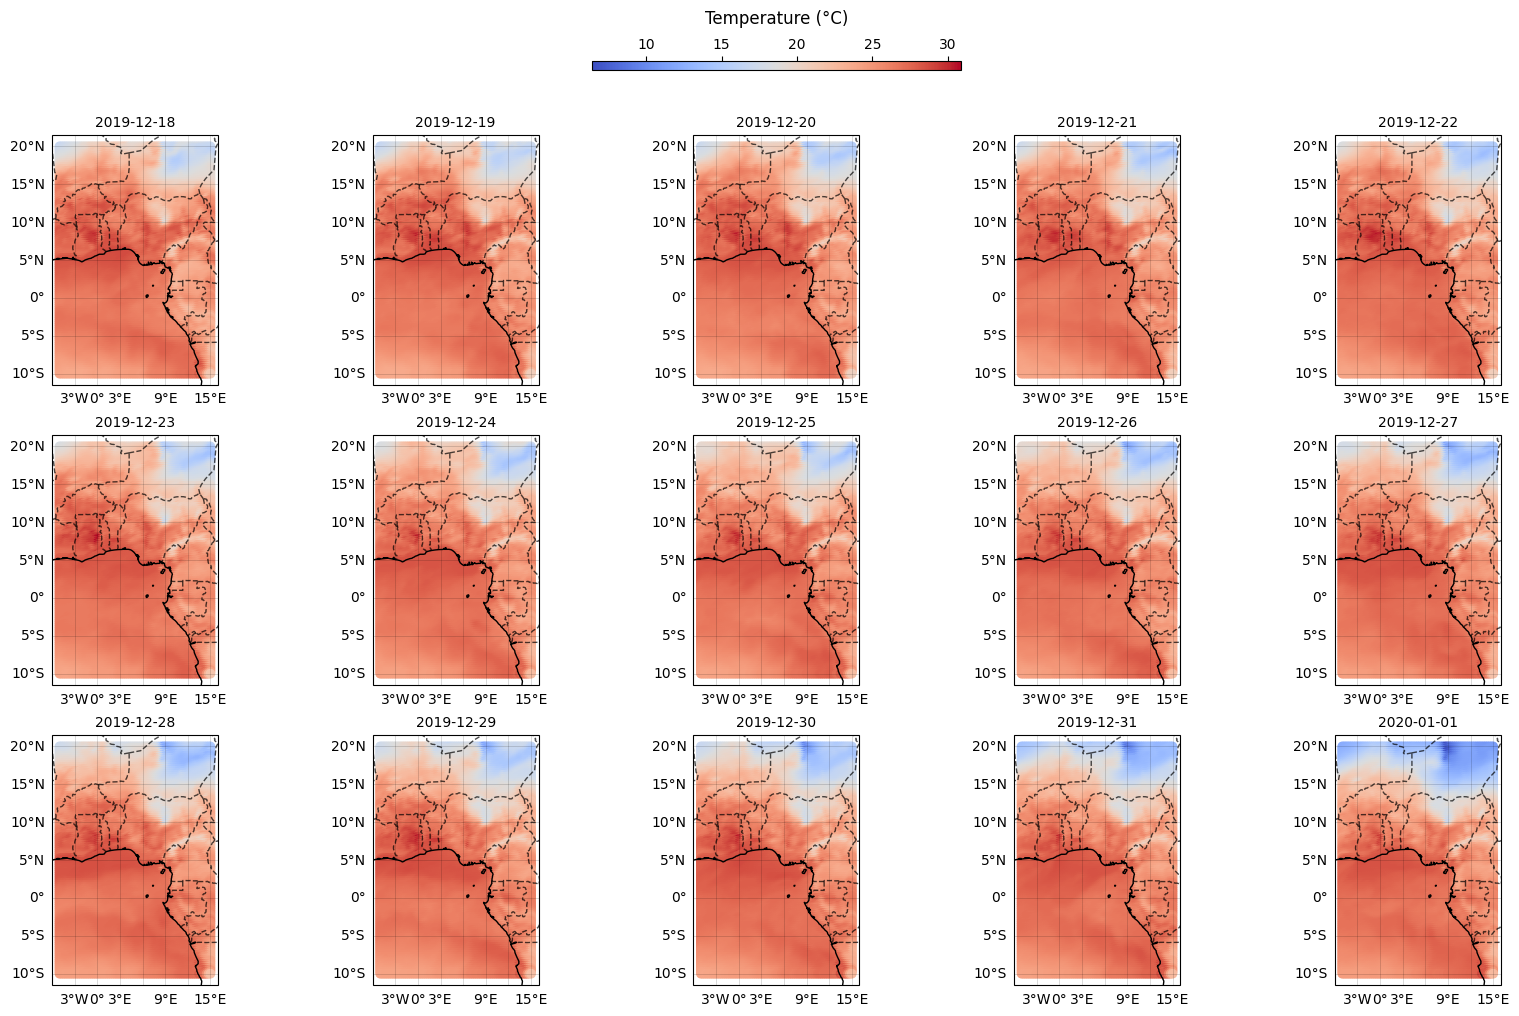

In [8]:
#2.2 a.i
fig, axes = subplot_gdf(
    gdfs,
    datetime_col='valid_time',
    column='t2m',
    ncols=5,
    cmap='coolwarm',
    legend_title='Temperature (°C)',
    #suptitle='Mean Temperature Over 15 Days'
)

plt.show()


In [ ]:
#2.2 a.ii 
# plot the 15 day anaomoly. Each day compared to the 15 days surrounding it for 1991-2020
# retrieve data surounding 15 days before leading up to the event and 15 days after the event totalling 45 days each year
start_year = 1991
end_year = 2020

all_gdfs = []


for year in range(start_year, end_year + 1):
    year_start = datetime(year=year, month=eventDate.month, day=eventDate.day) - timedelta(days=29)
    year_end = datetime(year=year, month=eventDate.month, day=eventDate.day) + timedelta(days=15)
    
    all_gdfs.append(DataClient(your_api_key).temperature_2m_mean(bbox, (year_start, year_end)))

final_gdf = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs=all_gdfs[0].crs)


2025-08-14 11:48:13,075 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-14 11:48:13,871 INFO Request ID is e863199f-153a-41b3-babc-23617159b08b
2025-08-14 11:48:13,934 INFO status has been updated to accepted
2025-08-14 11:48:20,478 INFO status has been updated to running
2025-08-14 11:49:31,322 INFO status has been updated to successful


2b02d2b06d50b4312a84a80631c3fcaf.nc:   0%|          | 0.00/600k [00:00<?, ?B/s]

2025-08-14 11:49:32,996 INFO Request ID is 1a6aa271-af6e-4e85-a4b2-cd20be57901b
2025-08-14 11:49:33,061 INFO status has been updated to accepted
2025-08-14 11:49:42,136 INFO status has been updated to successful


75f5b9ab831a2ccae3943c66825acf26.nc:   0%|          | 0.00/339k [00:00<?, ?B/s]

2025-08-14 11:49:43,103 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-14 11:49:43,634 INFO Request ID is 2b937ee4-d464-448c-9a77-9e779aeea7d5
2025-08-14 11:49:43,716 INFO status has been updated to accepted
2025-08-14 11:49:57,215 INFO status has been updated to successful


...

afc3d4ac5c6ca30d3918f9eaca356bef.nc:   0%|          | 0.00/338k [00:00<?, ?B/s]

2025-08-14 12:08:59,530 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-14 12:09:00,032 INFO Request ID is 30992387-26d3-4c9f-9485-fff0654aa2fc
2025-08-14 12:09:00,076 INFO status has been updated to accepted
2025-08-14 12:09:13,887 INFO status has been updated to successful


e0427d18b03d02403dcae9df491d707c.nc:   0%|          | 0.00/603k [00:00<?, ?B/s]

2025-08-14 12:09:15,995 INFO Request ID is f765bf5d-6709-4e66-901e-afd2f35ec8b1
2025-08-14 12:09:16,046 INFO status has been updated to accepted
2025-08-14 12:09:37,345 INFO status has been updated to successful


3b3eedba1ee169fc98a22f0bc055a85a.nc:   0%|          | 0.00/339k [00:00<?, ?B/s]

In [29]:
final_gdf.to_file("../data/1991-2020_t2m.gpkg", layer="1991-2020_t2m", driver="GPKG")


In [ ]:
# 2.2 anomaly

def subtract_mean_anomaly(final_gdf, gdfs, value_col="t2m"):
    # Ensure datetime columns
    final_gdf = final_gdf.copy()
    gdfs = gdfs.copy()
    final_gdf["valid_time"] = pd.to_datetime(final_gdf["valid_time"])
    gdfs["valid_time"] = pd.to_datetime(gdfs["valid_time"])
    
    # Prepare list for adjusted results
    adjusted_list = []
    
    for target_date in gdfs["valid_time"].unique():
        # --- Step 1: get mean around date for all years ---
        results = []
        for year in final_gdf["valid_time"].dt.year.unique():
            center_date = datetime(year, target_date.month, target_date.day)
            start_window = center_date - timedelta(days=15)
            end_window = center_date + timedelta(days=15)
            
            subset = final_gdf[
                (final_gdf["valid_time"] >= start_window) &
                (final_gdf["valid_time"] <= end_window)
            ]
            results.append(subset)
        
        combined = pd.concat(results, ignore_index=True)
        mean_gdf = combined.groupby("geometry")[value_col].mean().reset_index()
        
        # --- Step 2: subtract from gdfs for this target date ---
        current_day_gdf = gdfs[gdfs["valid_time"] == target_date]
        
        # Merge on geometry so subtraction matches locations
        merged = current_day_gdf.merge(mean_gdf, on="geometry", suffixes=("", "_mean"))
        merged[value_col] = merged[value_col] - merged[f"{value_col}_mean"]
        merged.drop(columns=[f"{value_col}_mean"], inplace=True)
        
        adjusted_list.append(merged)
    
    # Combine adjusted daily frames back together
    final_adjusted_gdf = gpd.GeoDataFrame(
        pd.concat(adjusted_list, ignore_index=True),
        crs=gdfs.crs
    )
    
    return final_adjusted_gdf

2025-08-11 13:00:28,464 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-11 13:00:29,363 INFO Request ID is 0c211b75-3286-4bf4-80c8-b2c36505b58f
2025-08-11 13:00:29,431 INFO status has been updated to accepted
2025-08-11 13:01:19,348 INFO status has been updated to running
2025-08-11 13:03:21,953 INFO status has been updated to successful


6f26999e2d29ac824e9848114e5339e.nc:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

2025-08-11 13:03:23,053 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-11 13:03:23,935 INFO Request ID is 6c7dae68-524b-452f-bddc-a518c1d5b5fc
2025-08-11 13:03:24,019 INFO status has been updated to accepted
2025-08-11 13:03:29,004 INFO status has been updated to running
2025-08-11 13:06:16,017 INFO status has been updated to successful


54d8c474769e36381811dbcb14974a8a.nc:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

2025-08-11 13:06:17,094 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-11 13:06:17,876 INFO Request ID is f9467222-5d7d-439c-a234-9914d9402f33
2025-08-11 13:06:17,959 INFO status has been updated to accepted
2025-08-11 13:06:26,526 INFO status has been updated to running
2025-08-11 13:08:12,181 INFO status has been updated to successful


...

2025-08-13 01:27:03,955 INFO Request ID is 0a8451e3-05d2-4fe9-b21e-987c1416cd16
2025-08-13 01:27:04,031 INFO status has been updated to accepted
2025-08-13 01:27:25,330 INFO status has been updated to running
2025-08-13 01:27:53,981 INFO status has been updated to successful


f4ca111a648ee004ed052e640b7c8997.nc:   0%|          | 0.00/379k [00:00<?, ?B/s]

2025-08-13 01:27:55,435 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-13 01:27:56,169 INFO Request ID is bf85f1e3-8f0b-4117-bdae-1b53ae93e1e2
2025-08-13 01:27:56,252 INFO status has been updated to accepted
2025-08-13 01:28:09,841 INFO status has been updated to running
2025-08-13 01:28:46,283 INFO status has been updated to successful


9fd562d22f5bd228127d178447f6dce3.nc:   0%|          | 0.00/262k [00:00<?, ?B/s]

2025-08-13 01:28:47,850 INFO Request ID is 11b08003-13ac-4f52-bcdf-2e0f3ea22639
2025-08-13 01:28:47,919 INFO status has been updated to accepted
2025-08-13 01:28:56,418 INFO status has been updated to running


In [ ]:
anomaly_gdf = subtract_mean_anomaly(final_gdf, gdfs)

fig, axes = subplot_gdf(
    anomaly_gdf,
    datetime_col='valid_time',
    column='t2m_mean',
    ncols=5,
    cmap='coolwarm',
    legend_title='Temperature (°C)',
    #suptitle='Mean Temperature Over 15 Days'
)

plt.show()

In [3]:
# 2.2 d
regionType = 'hydrobasin' # 'wraf' or 'hydrobasin'

# select region
result = select_region(regionType)
# interpret the result as JSON
data = json.loads(result)

# convert data to polygons and coordinates
polygons, coords = data_2_poly(data)

Region Picker started successfully for hydrobasin:
Polling for region selection...


KeyboardInterrupt: 

c:\Python310\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\jasper\AppData\Local\Temp\ipykernel_7396\1725737792.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


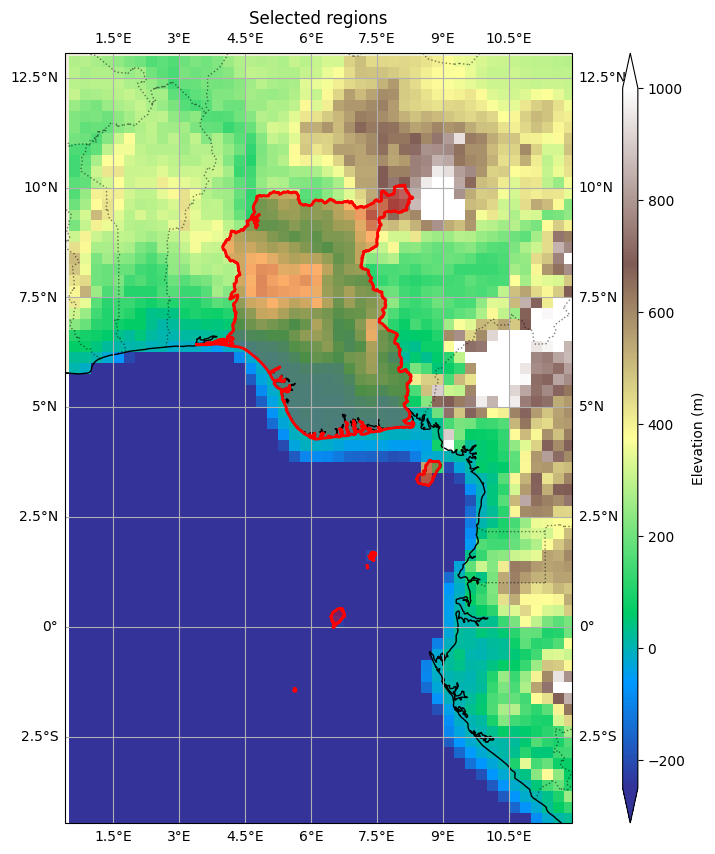

In [66]:
#2.2 d/e
# load elevation data from a NetCDF file
elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

# plot polygon, elevation is optional
fig, ax = plot_poly(polygons, coords, elevation=elevation)

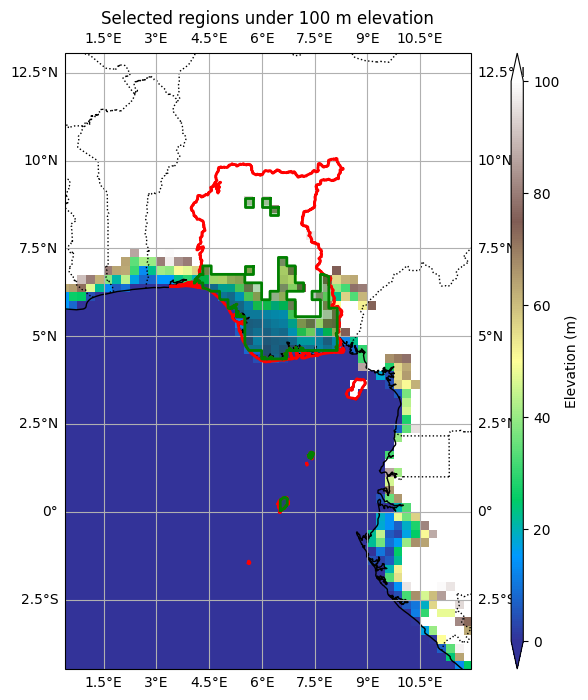

In [67]:
#2.2 e
# plot polygons based on selected region and elevation threshold
elevation_threshold = 100  # meters
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

In [68]:
# 2.2 e
# write polygons to a shapefile
multipoly = unary_union(adjusted_polygons)
gdf = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    # is this using the correct CRS?
gdf.to_file("..\data\sf_studyregion.shp")

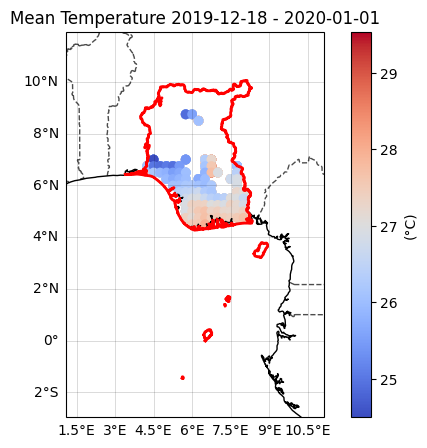

In [ ]:
#2.2 e
# intersect gdf with polygons we created to only display data for the selected region and elevation

poly_shp = gpd.read_file("..\data\sf_studyregion.shp")
poly_gdf = gpd.GeoDataFrame(geometry=poly_shp.geometry, crs=poly_shp.crs)

# This is used in the original code but does not work with our poly, since the gdf.overlay works I won't be spending more time to fix this
#rm = regionmask.mask_geopandas(poly_gdf, gdf_selection)

# intersect a GeoDataFrame with the polygon
#intersected = gpd.overlay(daily_gdfs[datetime(2020, 1, 1).date()], poly_gdf, how='intersection')
#intersected = gpd.overlay(gdf_selection, poly_gdf, how='intersection')
intersected = gpd.overlay(gdfs, poly_gdf, how='intersection')

# optional extends for a bigger area
min_lon, min_lat, max_lon, max_lat = poly_gdf.total_bounds
extends = [min_lon - 3, max_lon + 3, min_lat - 3, max_lat + 3]

# display the intersection results
fig, ax = plot_gdf(intersected, title=f"Mean Temperature {date1.strftime('%Y-%m-%d')} - {eventDate.strftime('%Y-%m-%d')}", legend_title="(°C)", cmap='coolwarm', extends=extends, polygons=polygons)
# Maybe add some padding to the results, this should be done in plot.py

# !!! OLD !!!
# display the intersection results
#fig = visualize_geo(intersected, 't2m', 'longitude', 'latitude', backend='plotly', zoom=4, width=500, height=400)
#fig.show()

In [ ]:
#2.3
# save the study domain (as shapefile)
intersected.to_file("..\data\sf_studyregion")

c:\Python310\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field valid_time create as date field, though DateTime requested.
  ogr_write(


In [ ]:

def plot_timeseries(data, title, x_label, y_label, label_rotation=0, dateformat="%Y-%m-%d", x_ticks=mdates.DayLocator(), color='darkblue', linewidth=2.0, linestyle='-'):

    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot directly onto the axes
    data.plot(ax=ax,
              color=color,     # line color
              linewidth=linewidth,        # line width
              linestyle=linestyle        # dashed line; use "-" for solid, ":" for dotted
              )

    

    # Set major ticks to the 1st of each month
    ax.xaxis.set_major_locator(x_ticks)

    # Format the ticks as full dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter(dateformat))

    # Rotate tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(label_rotation)
        label.set_horizontalalignment("right")

    # Set title and axis labels
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # Add grid
    ax.grid(True)

    # Make sure everything fits
    fig.tight_layout()

    return fig, ax

Mean temperature: 27.176764
Mean temperature: valid_time
2019-12-18    27.480978
2019-12-19    28.113420
2019-12-20    28.064623
2019-12-21    27.590742
2019-12-22    27.283928
2019-12-23    27.164425
2019-12-24    26.760094
2019-12-25    27.228437
2019-12-26    27.278318
2019-12-27    27.270332
2019-12-28    26.939251
2019-12-29    26.630789
2019-12-30    26.525648
2019-12-31    26.715069
2020-01-01    26.605412
Name: t2m, dtype: float32


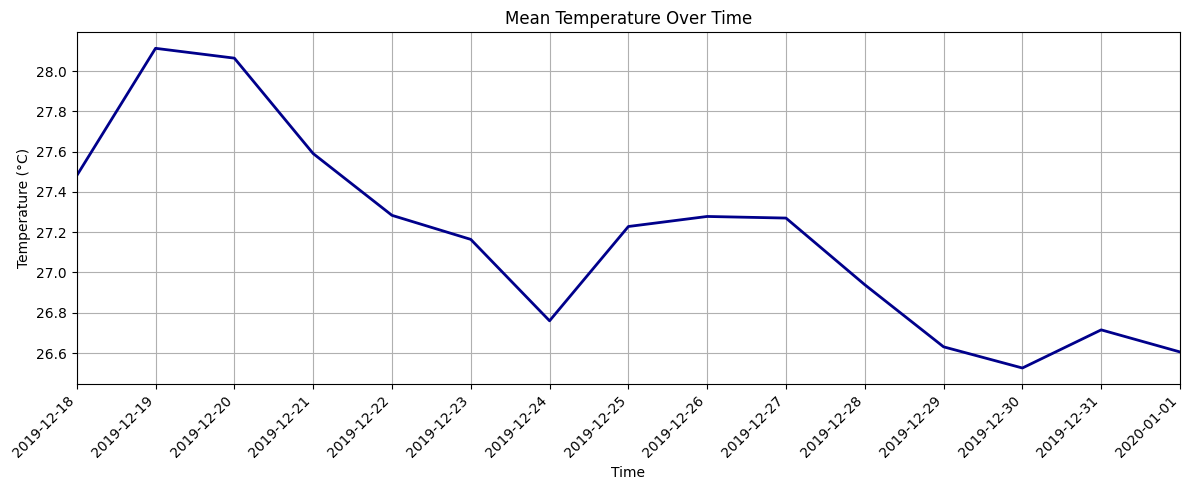

In [72]:
#2.4
#plot timeseries for retrieved data for selected region and elevation

# mean over the entire intersection
mean_temp = intersected["t2m"].mean()
print("Mean temperature:", mean_temp)

# mean temperature per time step
mean_ts = intersected.groupby("valid_time")["t2m"].mean()
print("Mean temperature:", mean_ts)

# Optional: save to NetCDF
mean_ts.to_xarray().to_netcdf("../data/avg_temperature.nc")
# OR CSV
mean_ts.to_csv("../data/avg_temperature.csv")

# plot the mean temperature over time
fig, ax = plot_timeseries(data=mean_ts, 
                title="Mean Temperature Over Time",
                x_label="Time",
                y_label="Temperature (°C)",
                label_rotation=45,
                dateformat="%Y-%m-%d",
                x_ticks=mdates.DayLocator())

In [ ]:
#2.5
# preticipation
event_date = datetime(2023, 7, 1)        # event date
date6 = datetime(2023, 12, 31)
date5 = datetime(2023, 1, 1)

gdfs = DataClient(your_api_key).total_precipitation(bbox, (date5, date6))
print(gdfs)

2025-07-28 10:46:45,107 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-28 10:46:45,802 INFO Request ID is 7728b022-b198-4f4f-a49a-6b4e7b854aaf
2025-07-28 10:46:45,873 INFO status has been updated to accepted
2025-07-28 10:48:01,378 INFO status has been updated to running
2025-07-28 10:59:04,965 INFO status has been updated to successful


e1c1c105f8951d3ea072fe7f7c76a1f6.nc:   0%|          | 0.00/4.82M [00:00<?, ?B/s]

        valid_time  latitude  longitude        tp  number           geometry
0       2023-01-01      20.0      -5.00  0.000000       0      POINT (-5 20)
1       2023-01-01      20.0      -4.75  0.000000       0   POINT (-4.75 20)
2       2023-01-01      20.0      -4.50  0.000000       0    POINT (-4.5 20)
3       2023-01-01      20.0      -4.25  0.000000       0   POINT (-4.25 20)
4       2023-01-01      20.0      -4.00  0.000000       0      POINT (-4 20)
...            ...       ...        ...       ...     ...                ...
3577360 2023-12-31     -10.0      14.00  0.000141       0     POINT (14 -10)
3577361 2023-12-31     -10.0      14.25  0.000037       0  POINT (14.25 -10)
3577362 2023-12-31     -10.0      14.50  0.000007       0   POINT (14.5 -10)
3577363 2023-12-31     -10.0      14.75  0.000669       0  POINT (14.75 -10)
3577364 2023-12-31     -10.0      15.00  0.001493       0     POINT (15 -10)

[3577365 rows x 6 columns]


In [ ]:
#2.5
# temperature
event_date = datetime(2023, 7, 1)        # event date
date6 = datetime(2023, 12, 31)
date5 = datetime(2023, 1, 1)

gdfs = DataClient(your_api_key).temperature_2m_mean(bbox, (date5, date6))
print(gdfs)

2025-07-28 13:36:57,380 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-07-28 13:36:57,921 INFO Request ID is 08d81123-5faa-483f-8d9f-fed4a3a6358e
2025-07-28 13:36:57,994 INFO status has been updated to accepted
2025-07-28 13:37:31,133 INFO status has been updated to running
2025-07-28 13:45:17,698 INFO status has been updated to successful


ab7b0a08519e23266eccad2b77e32ed.nc:   0%|          | 0.00/7.02M [00:00<?, ?B/s]

        valid_time  latitude  longitude        t2m  number           geometry
0       2023-01-01      20.0      -5.00  18.837097       0      POINT (-5 20)
1       2023-01-01      20.0      -4.75  19.052124       0   POINT (-4.75 20)
2       2023-01-01      20.0      -4.50  19.255737       0    POINT (-4.5 20)
3       2023-01-01      20.0      -4.25  19.358917       0   POINT (-4.25 20)
4       2023-01-01      20.0      -4.00  19.382355       0      POINT (-4 20)
...            ...       ...        ...        ...     ...                ...
3577360 2023-12-31     -10.0      14.00  27.294861       0     POINT (14 -10)
3577361 2023-12-31     -10.0      14.25  26.855560       0  POINT (14.25 -10)
3577362 2023-12-31     -10.0      14.50  25.690125       0   POINT (14.5 -10)
3577363 2023-12-31     -10.0      14.75  24.026367       0  POINT (14.75 -10)
3577364 2023-12-31     -10.0      15.00  22.740173       0     POINT (15 -10)

[3577365 rows x 6 columns]


In [ ]:
#2.5
# creating labels and intersecting with polygons
days = pd.date_range(start = "2020-01-01", end = "2020-12-31")
labelticks = [i+1 for i in range(365) if (days[i].day) == 1]
labels = [days[i].strftime("%b") for i in range(366) if (days[i].day) == 1]

intersected = gpd.overlay(gdfs, poly_gdf, how='intersection')

In [ ]:
def ddn_day_accumulations_gdf(data, column, parameter, labelticks, labels, time_column="valid_time", days=None, ylimit=None):

    fig, axs = plt.subplots(ncols=4, figsize=(20, 3), dpi=100, sharey=True)

    # Ensure datetime and sorted
    data = data.copy()
    data[time_column] = pd.to_datetime(data[time_column])
    data = data.sort_values(time_column)

    for i in range(4):
        ax = axs[i]

        # Determine n-day window
        if days is not None:
            ndays = days[i]
        elif column == 't2m':
            ndays = [1, 3, 7, 14][i]
        elif column == 'tp':
            ndays = [1, 3, 5, 10][i]
        else:
            ndays = [1, 3, 5, 11][i]

        if column is "tp":
            data_nday = (
                data.set_index(time_column)
                    [column]
                    .rolling(ndays, min_periods=1, center=False)
                    .sum()
                    .reset_index()
            )
        else:
            data_nday = (
                data.set_index(time_column)
                    [column]
                    .rolling(ndays, min_periods=1, center=False)
                    .mean()
                    .reset_index()
            )


        # Plot each year in blue
        for y in data_nday[time_column].dt.year.unique():
            data_y = data_nday[data_nday[time_column].dt.year == y]
            ax.plot(
                data_y[time_column].dt.dayofyear,
                data_y[column],
                color="tab:blue",
                alpha=0.3
            )

        # Style the plot
        ax.set_xticks(labelticks)
        ax.set_xticklabels(labels)
        ax.grid(axis="x", color="k", alpha=0.2)
        ax.set_title(f"{ndays}-day accumulated {parameter}")

        # Highlight date window
        ylim = ax.get_ylim()
        print(ylim)

        dayofyear = pd.to_datetime(event_date).dayofyear
        ax.add_patch(Rectangle((dayofyear, ylim[0]), -15, 10000,
                               color="gold", alpha=0.3))
        ax.set_ylim(ylim)

        # Highlight selected year
        year2 = pd.to_datetime(event_date)
        data_y = data_nday[data_nday[time_column] <= year2]
        ax.plot(data_y[time_column].dt.dayofyear, data_y[column], color="k")

    if ylimit is not None:
        ax.set_ylim(0, ylimit)

    return fig, axs

<>:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\jasper\AppData\Local\Temp\ipykernel_7396\4131138138.py:23: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if column is "tp":


(np.float64(22.906695556640624), np.float64(35.11881713867187))
(np.float64(22.906695556640624), np.float64(35.11881713867187))
(np.float64(22.906695556640624), np.float64(35.11881713867187))
(np.float64(22.906695556640624), np.float64(35.11881713867187))


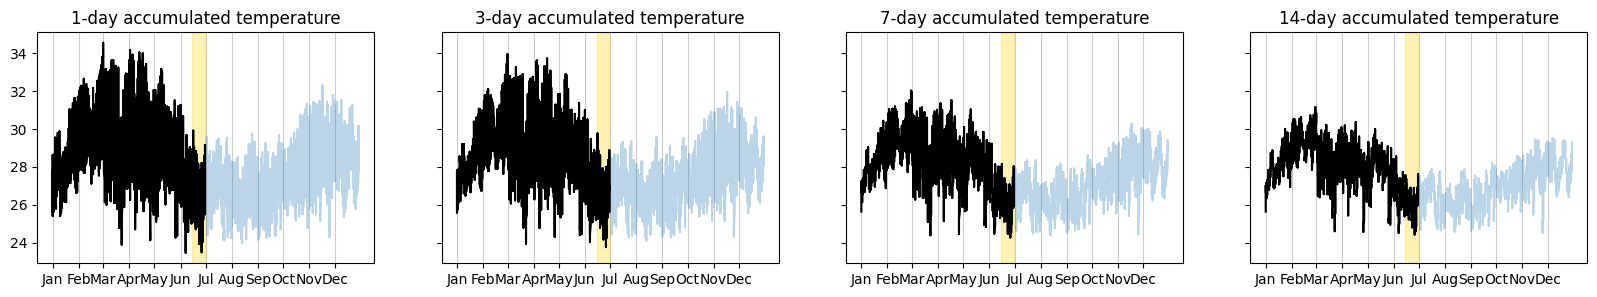

In [ ]:
#2.5
# unclear requirements
# current year to the curent date?
# we have now only taken the current year and up to the event date
fig, axs = n_day_accumulations_gdf(data=intersected, column='t2m', parameter='temperature', labelticks=labelticks, labels=labels)

In [ ]:
#2.6
# unclear requirements

In [ ]:
#2.7
# unclear requirements


In [ ]:
#2.8

In [ ]:
#2.9
# read station data time series from .xls

In [ ]:
#2.10

In [ ]:
#2.11

In [ ]:
#2.12

In [ ]:
#2.13
# unclear requirements

In [ ]:
#2.14
# unclear requirements

In [ ]:
#2.15
# unclear requirements